# Home Credit Default Risk Classification Problem

## Objective

The objective of the Home Credit Default Risk Classification problem is to build a machine learning model that can predict whether a loan applicant will have difficulty repaying a loan. Specifically, the task is to classify clients into two categories:

- **0** → Client will repay the loan on time
- **1** → Client is likely to default or face payment difficulties

The primary goal is to help financial institutions minimize credit risk while ensuring that capable borrowers are not rejected unnecessarily.

---

## Problem Description

Many individuals with limited or no credit history struggle to obtain loans from traditional financial institutions. Home Credit aims to expand financial inclusion by using alternative data sources and predictive analytics to assess borrower reliability.

In this classification problem:

- Historical customer data is provided, including:
  - Demographic information
  - Financial status
  - Employment details
  - Previous credit history
  - Loan application information

- The target variable is:
  - `TARGET`
    - `0` → No payment difficulties
    - `1` → Payment difficulties/default

The challenge is to analyze the given features and train a supervised machine learning classification model that accurately predicts the probability of default for new applicants.

---

## Business Impact

A successful model can help:

- Reduce financial losses from loan defaults
- Improve loan approval decisions
- Increase access to credit for underserved populations
- Enhance customer risk assessment processes

---

## Typical Machine Learning Approaches

Common algorithms used for this problem include:

- Logistic Regression
- Decision Trees
- Random Forest
- XGBoost
- LightGBM
- CatBoost

Evaluation metrics often include:

- ROC-AUC Score
- Precision
- Recall
- F1-Score

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/drive/MyDrive/Home Credit/application_train.csv")

In [ ]:
df.shape

(307511, 122)

In [ ]:
df['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


In [ ]:
def optimize_memory(df):

    # ============================================
    # MEMORY BEFORE OPTIMIZATION
    # ============================================

    start_memory = df.memory_usage(deep=True).sum() / 1024**2

    print(f"\nMemory Usage Before Optimization : {start_memory:.2f} MB\n")

    print("Before Optimization Dtypes:\n")
    print(df.dtypes)

    print("\n========================================\n")

    # ============================================
    # OPTIMIZATION LOGIC
    # ============================================

    for col in df.columns:

        col_type = df[col].dtype

        # ----------------------------------------
        # INTEGER OPTIMIZATION
        # ----------------------------------------

        if pd.api.types.is_integer_dtype(col_type):

            c_min = df[col].min()
            c_max = df[col].max()

            # SIGNED INTEGER

            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)

            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)

            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)

            else:
                df[col] = df[col].astype(np.int64)


        # ----------------------------------------
        # FLOAT OPTIMIZATION
        # ----------------------------------------

        elif pd.api.types.is_float_dtype(col_type):

            c_min = df[col].min()
            c_max = df[col].max()

            if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)

            elif c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

            else:
                df[col] = df[col].astype(np.float64)


    # ============================================
    # MEMORY AFTER OPTIMIZATION
    # ============================================

    end_memory = df.memory_usage(deep=True).sum() / 1024**2

    print("After Optimization Dtypes:\n")
    print(df.dtypes)

    print("\n========================================\n")

    print(f"Memory Usage After Optimization  : {end_memory:.2f} MB")

    reduction = ((start_memory - end_memory) / start_memory) * 100

    print(f"Memory Reduced By                : {reduction:.2f}%")

    return df

In [ ]:
df_memory_optimized=optimize_memory(df)


Memory Usage Before Optimization : 504.99 MB

Before Optimization Dtypes:

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object




/tmp/ipykernel_8466/2267550834.py:57: RuntimeWarning: overflow encountered in cast
  if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
/tmp/ipykernel_8466/2267550834.py:57: RuntimeWarning: overflow encountered in cast
  if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
/tmp/ipykernel_8466/2267550834.py:57: RuntimeWarning: overflow encountered in cast
  if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
/tmp/ipykernel_8466/2267550834.py:57: RuntimeWarning: overflow encountered in cast
  if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:


After Optimization Dtypes:

SK_ID_CURR                      int32
TARGET                           int8
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float16
AMT_REQ_CREDIT_BUREAU_WEEK    float16
AMT_REQ_CREDIT_BUREAU_MON     float16
AMT_REQ_CREDIT_BUREAU_QRT     float16
AMT_REQ_CREDIT_BUREAU_YEAR    float16
Length: 122, dtype: object


Memory Usage After Optimization  : 311.14 MB
Memory Reduced By                : 38.39%


In [ ]:
def null_value_treatment(df, threshold=40):

    # =====================================================
    # NULL VALUES BEFORE TREATMENT
    # =====================================================

    print("\n========== NULL VALUE REPORT BEFORE ==========\n")

    null_before = pd.DataFrame({
        "Null_Count": df.isnull().sum(),
        "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
        "Dtype": df.dtypes
    })

    print(null_before)

    print("\n================================================\n")


    # =====================================================
    # NULL VALUE TREATMENT
    # =====================================================

    dropped_columns = []
    filled_columns = []

    for col in df.columns:

        null_percentage = (df[col].isnull().sum() / len(df)) * 100


        # -------------------------------------------------
        # DROP COLUMN IF NULL % > THRESHOLD
        # -------------------------------------------------

        if null_percentage > threshold:

            dropped_columns.append(col)


        # -------------------------------------------------
        # NUMERICAL COLUMN TREATMENT
        # -------------------------------------------------

        else:

            if pd.api.types.is_numeric_dtype(df[col]):

                df[col] = df[col].fillna(df[col].median())

                filled_columns.append((col, "Median"))


            # -------------------------------------------------
            # CATEGORICAL COLUMN TREATMENT
            # -------------------------------------------------

            else:

                df[col] = df[col].fillna(df[col].mode()[0])

                filled_columns.append((col, "Mode"))


    # =====================================================
    # DROP HIGH NULL VALUE COLUMNS
    # =====================================================

    df.drop(columns=dropped_columns, inplace=True)


    # =====================================================
    # NULL VALUES AFTER TREATMENT
    # =====================================================

    print("Dropped Columns:\n")
    print(dropped_columns)

    print("\n================================================\n")

    print("Filled Columns:\n")

    for col, method in filled_columns:
        print(f"{col}  --> Filled Using {method}")


    print("\n================================================\n")

    print("\n========== NULL VALUE REPORT AFTER ==========\n")

    null_after = pd.DataFrame({
        "Null_Count": df.isnull().sum(),
        "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
        "Dtype": df.dtypes
    })

    print(null_after)

    print("\n================================================\n")

    return df


In [ ]:
df_null_value=null_value_treatment(df_memory_optimized,30)


========== NULL VALUE REPORT BEFORE ==========

                            Null_Count  Null_Percentage    Dtype
SK_ID_CURR                           0         0.000000    int32
TARGET                               0         0.000000     int8
NAME_CONTRACT_TYPE                   0         0.000000   object
CODE_GENDER                          0         0.000000   object
FLAG_OWN_CAR                         0         0.000000   object
...                                ...              ...      ...
AMT_REQ_CREDIT_BUREAU_DAY        41519        13.501631  float16
AMT_REQ_CREDIT_BUREAU_WEEK       41519        13.501631  float16
AMT_REQ_CREDIT_BUREAU_MON        41519        13.501631  float16
AMT_REQ_CREDIT_BUREAU_QRT        41519        13.501631  float16
AMT_REQ_CREDIT_BUREAU_YEAR       41519        13.501631  float16

[122 rows x 3 columns]


Dropped Columns:

['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
# def outlier_treatment(df, method="iqr"):

#     # =====================================================
#     # OUTLIER REPORT BEFORE TREATMENT
#     # =====================================================

#     print("\n========== OUTLIER REPORT BEFORE ==========\n")

#     numeric_cols = df.select_dtypes(include=np.number).columns

#     outlier_summary_before = {}

#     for col in numeric_cols:

#         if method == "iqr":

#             Q1 = df[col].quantile(0.25)
#             Q3 = df[col].quantile(0.75)
#             IQR = Q3 - Q1

#             lower_bound = Q1 - 1.5 * IQR
#             upper_bound = Q3 + 1.5 * IQR

#             outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

#             outlier_summary_before[col] = len(outliers)


#     print(pd.DataFrame.from_dict(
#         outlier_summary_before,
#         orient='index',
#         columns=['Outlier_Count']
#     ))

#     print("\n================================================\n")


#     # =====================================================
#     # OUTLIER TREATMENT
#     # =====================================================

#     treated_columns = []

#     for col in numeric_cols:

#         if method == "iqr":

#             Q1 = df[col].quantile(0.25)
#             Q3 = df[col].quantile(0.75)
#             IQR = Q3 - Q1

#             lower_bound = Q1 - 1.5 * IQR
#             upper_bound = Q3 + 1.5 * IQR


#             # -------------------------------------------------
#             # CAPPING OUTLIERS
#             # -------------------------------------------------

#             df[col] = np.where(
#                 df[col] < lower_bound,
#                 lower_bound,
#                 df[col]
#             )

#             df[col] = np.where(
#                 df[col] > upper_bound,
#                 upper_bound,
#                 df[col]
#             )

#             treated_columns.append(col)


#     # =====================================================
#     # OUTLIER REPORT AFTER TREATMENT
#     # =====================================================

#     print("Treated Columns:\n")

#     for col in treated_columns:
#         print(col)

#     print("\n================================================\n")

#     print("\n========== OUTLIER REPORT AFTER ==========\n")

#     outlier_summary_after = {}

#     for col in numeric_cols:

#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1

#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR

#         outliers = df[
#             (df[col] < lower_bound) |
#             (df[col] > upper_bound)
#         ]

#         outlier_summary_after[col] = len(outliers)


#     print(pd.DataFrame.from_dict(
#         outlier_summary_after,
#         orient='index',
#         columns=['Outlier_Count']
#     ))

#     print("\n================================================\n")

#     return df

In [ ]:
# df_outliers=outlier_treatment(df)

In [ ]:
df_outliers

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002.0,0.0,0,1,0,1,0.0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003.0,0.0,0,0,0,0,0.0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004.0,0.0,1,1,1,1,0.0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006.0,0.0,0,0,0,1,0.0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007.0,0.0,0,1,0,1,0.0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251.0,0.0,0,1,0,0,0.0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
307507,456252.0,0.0,0,0,0,1,0.0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
307508,456253.0,0.0,0,0,0,1,0.0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
307509,456254.0,0.0,0,0,0,1,0.0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def label_encoding(df):

    # =====================================================
    # BEFORE LABEL ENCODING
    # =====================================================

    print("\n========== BEFORE LABEL ENCODING ==========\n")

    object_cols = df.select_dtypes(include='object').columns

    print("Categorical Columns:\n")
    print(object_cols)

    print("\n================================================\n")


    # =====================================================
    # LABEL ENCODING
    # =====================================================

    label_encoders = {}

    for col in object_cols:

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col].astype(str))

        label_encoders[col] = dict(
            zip(le.classes_, le.transform(le.classes_))
        )


    # =====================================================
    # AFTER LABEL ENCODING
    # =====================================================

    print("\n========== AFTER LABEL ENCODING ==========\n")

    print(df.head())

    print("\n================================================\n")

    print("\nEncoding Mapping:\n")

    for col, mapping in label_encoders.items():

        print(f"\nColumn : {col}")
        print(mapping)

    print("\n================================================\n")

    return df

In [ ]:
df_label_encoded=label_encoding(df)


========== BEFORE LABEL ENCODING ==========

Categorical Columns:

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START',
       'ORGANIZATION_TYPE'],
      dtype='object')



========== AFTER LABEL ENCODING ==========

   SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  \
0      100002       1                   0            1             0   
1      100003       0                   0            0             0   
2      100004       0                   1            1             1   
3      100006       0                   0            0             0   
4      100007       0                   0            1             0   

   FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0                1             0          202500.0    406597.5      24700.5   
1              

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [ ]:
df_label_encoded.dtypes

,0
SK_ID_CURR,int32
TARGET,int8
NAME_CONTRACT_TYPE,int64
CODE_GENDER,int64
FLAG_OWN_CAR,int64
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float16
AMT_REQ_CREDIT_BUREAU_WEEK,float16
AMT_REQ_CREDIT_BUREAU_MON,float16
AMT_REQ_CREDIT_BUREAU_QRT,float16


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualization_analysis(df, target_col=None):

    # =====================================================
    # UNIVARIATE ANALYSIS
    # =====================================================

    print("\n========== UNIVARIATE ANALYSIS ==========\n")

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object']).columns


    # -----------------------------------------------------
    # NUMERICAL COLUMNS
    # -----------------------------------------------------

    for col in numeric_cols:

        plt.figure(figsize=(6,4))

        sns.histplot(df[col], kde=True)

        plt.title(f"Histogram of {col}")

        plt.show()


        plt.figure(figsize=(6,4))

        sns.boxplot(x=df[col])

        plt.title(f"Boxplot of {col}")

        plt.show()


    # -----------------------------------------------------
    # CATEGORICAL COLUMNS
    # -----------------------------------------------------

    for col in categorical_cols:

        plt.figure(figsize=(6,4))

        sns.countplot(x=df[col])

        plt.title(f"Countplot of {col}")

        plt.xticks(rotation=45)

        plt.show()


    # =====================================================
    # BIVARIATE ANALYSIS
    # =====================================================

    print("\n========== BIVARIATE ANALYSIS ==========\n")


    # -----------------------------------------------------
    # NUMERIC vs NUMERIC
    # -----------------------------------------------------

    for i in range(len(numeric_cols)):

        for j in range(i + 1, len(numeric_cols)):

            plt.figure(figsize=(6,4))

            sns.scatterplot(
                x=df[numeric_cols[i]],
                y=df[numeric_cols[j]]
            )

            plt.title(f"{numeric_cols[i]} vs {numeric_cols[j]}")

            plt.show()


    # -----------------------------------------------------
    # CATEGORICAL vs NUMERIC
    # -----------------------------------------------------

    for cat_col in categorical_cols:

        for num_col in numeric_cols:

            plt.figure(figsize=(6,4))

            sns.boxplot(
                x=df[cat_col],
                y=df[num_col]
            )

            plt.title(f"{cat_col} vs {num_col}")

            plt.xticks(rotation=45)

            plt.show()


    # -----------------------------------------------------
    # CORRELATION HEATMAP
    # -----------------------------------------------------

    if len(numeric_cols) > 1:

        plt.figure(figsize=(8,6))

        sns.heatmap(
            df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm'
        )

        plt.title("Correlation Heatmap")

        plt.show()


========== UNIVARIATE ANALYSIS ==========



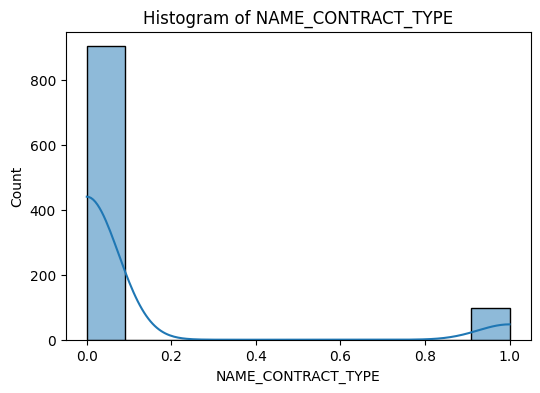

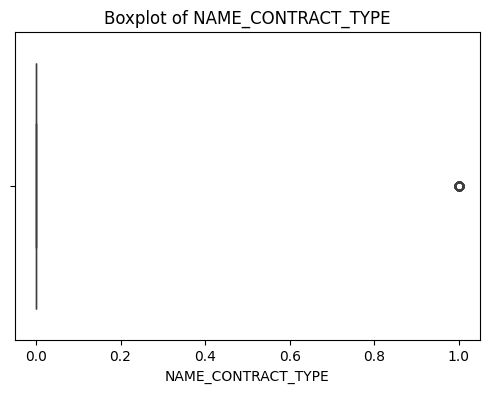

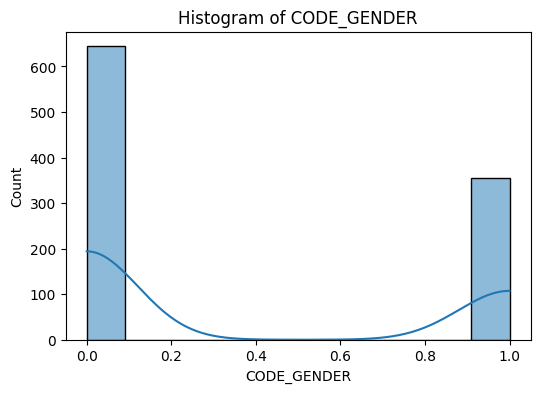

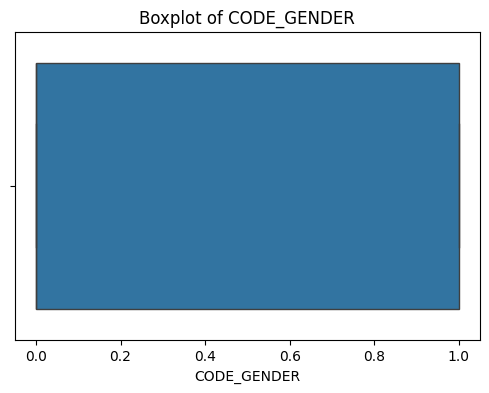

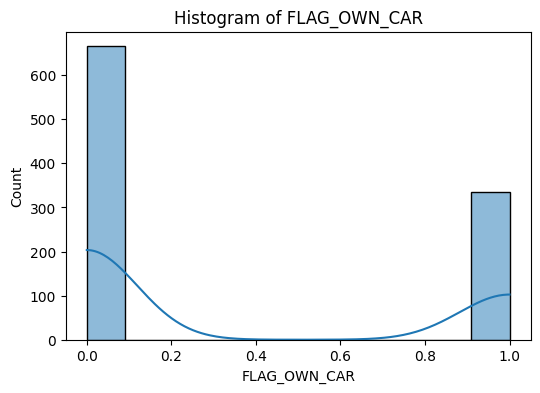

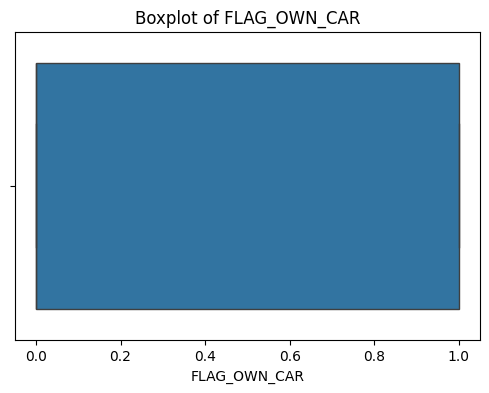

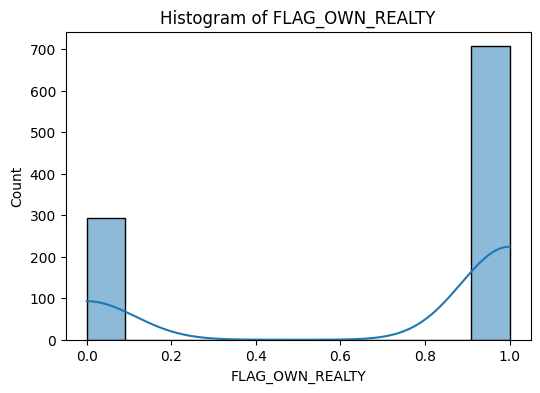

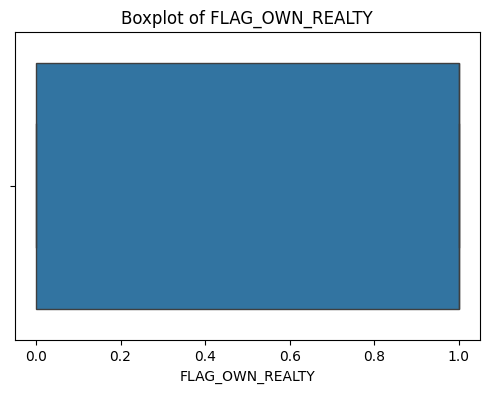


========== BIVARIATE ANALYSIS ==========



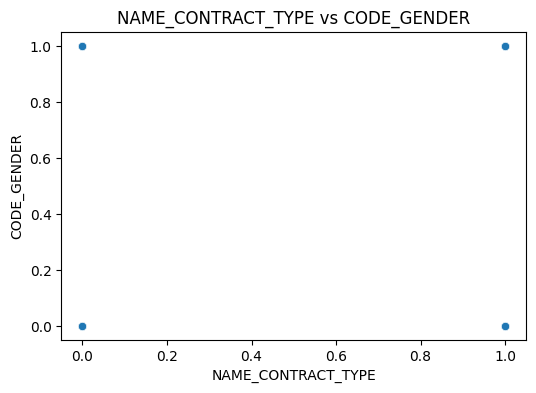

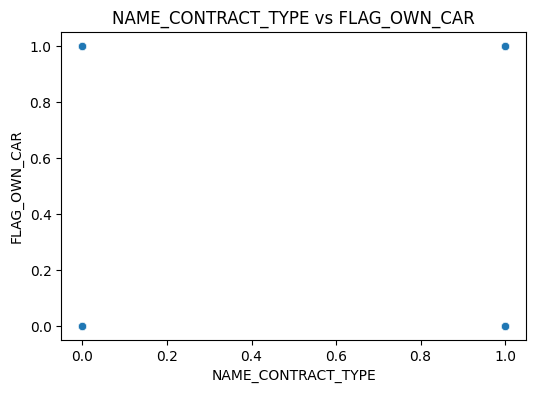

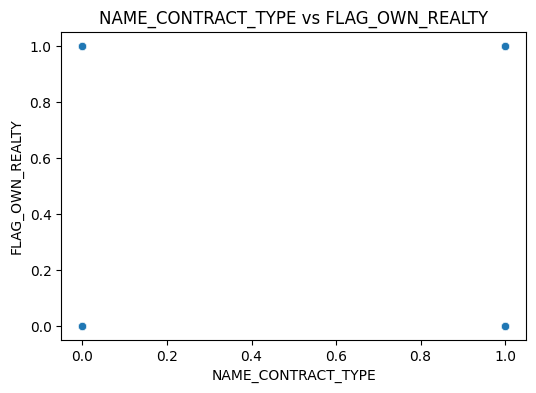

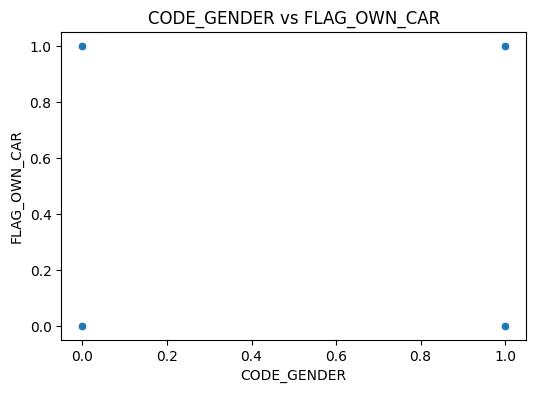

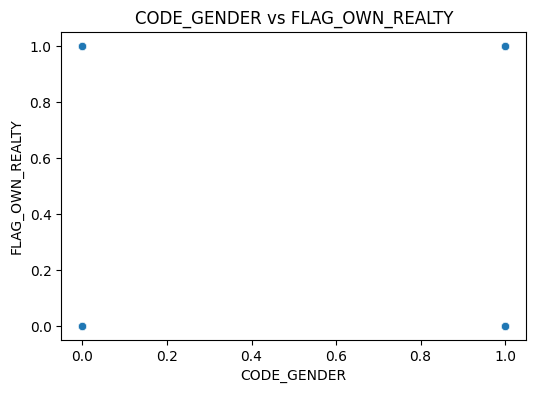

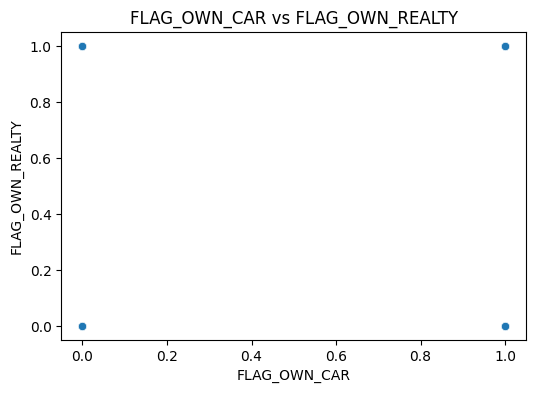

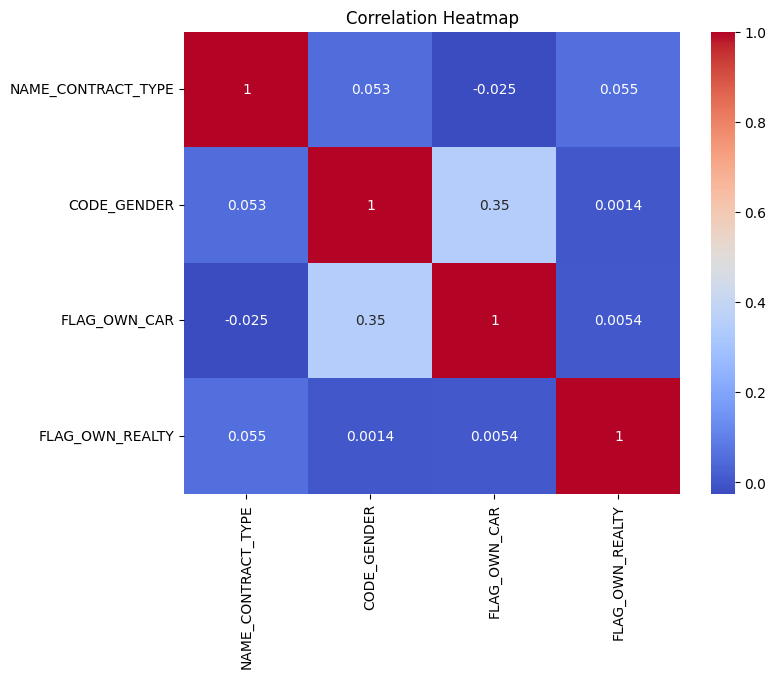

In [ ]:
visualization_analysis(df_label_encoded.iloc[0:1000,0:10])

In [ ]:
df['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================================
# MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# METRICS
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# MAIN FUNCTION
# =========================================================

def classification_models(df, target_column):

    # =====================================================
    # SPLITTING DATA
    # =====================================================

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )


    # =====================================================
    # FEATURE SCALING
    # =====================================================

    numeric_cols = X_train.select_dtypes(include=np.number).columns

    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


    # =====================================================
    # MODELS
    # =====================================================

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "SVM": SVC(probability=True, random_state=42, class_weight='balanced'),
        "KNN": KNeighborsClassifier()
    }


    # =====================================================
    # RESULTS STORAGE
    # =====================================================

    results = []


    # =====================================================
    # MODEL TRAINING AND EVALUATION
    # =====================================================

    for model_name, model in models.items():

        print(f"\nTraining {model_name} ...")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # Check if the model has predict_proba (e.g., some SVM configurations might not)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            # For models without predict_proba, ROC AUC might not be directly calculable
            # or might require different methods (e.g., decision_function for SVC)
            # For simplicity, we'll assign a placeholder or skip if not available
            y_prob = np.full(len(y_test), np.nan) # Placeholder


        # =================================================
        # METRICS (only compute the 5 important ones)
        # =================================================

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Calculate ROC AUC only if y_prob is available
        if not np.isnan(y_prob).all():
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan # Assign NaN if y_prob not available

        # Print metrics for the current model
        print(f"--- {model_name} Metrics ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")


        # =================================================
        # STORE RESULTS
        # =================================================

        results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        })


    # =====================================================
    # FINAL RESULTS DATAFRAME
    # =====================================================

    results_df = pd.DataFrame(results)

    return results_df




# =========================================================
# FUNCTION CALL
# =========================================================

final_results = classification_models(df_label_encoded.sample(10000, random_state=42), "TARGET")

print("\n================ FINAL METRICS SUMMARY =================\n")

print(final_results)


Training Logistic Regression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression Metrics ---
Accuracy: 0.6050
Precision: 0.1152
Recall: 0.6443
F1 Score: 0.1955
ROC AUC: 0.6419

Training Decision Tree ...
--- Decision Tree Metrics ---
Accuracy: 0.8605
Precision: 0.1131
Recall: 0.1275
F1 Score: 0.1199
ROC AUC: 0.5235

Training Random Forest ...
--- Random Forest Metrics ---
Accuracy: 0.9255
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.6885

Training SVM ...
--- SVM Metrics ---
Accuracy: 0.4765
Precision: 0.0881
Recall: 0.6443
F1 Score: 0.1550
ROC AUC: 0.5844

Training KNN ...
--- KNN Metrics ---
Accuracy: 0.9205
Precision: 0.0833
Recall: 0.0067
F1 Score: 0.0124
ROC AUC: 0.4792

================ FINAL METRICS SUMMARY =================

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression    0.6050   0.115246  0.644295  0.195519  0.641935
1        Decision Tree    0.8605   0.113095  0.127517  0.119874  0.523510
2        Random Forest    0.9255   0.000000  0.000000  0.000000  0.688500
3 

In [ ]:
import pandas as pd
import numpy as np
import joblib # Import joblib for saving models
import os # Import os for directory operations

from sklearn.model_selection import train_test_split, GridSearchCV # Added GridSearchCV
from sklearn.preprocessing import StandardScaler

# =========================================================
# MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# METRICS
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# MAIN FUNCTION (MODIFIED)
# =========================================================

def classification_models_with_tuning_and_saving(df, target_column):

    # Drop SK_ID_CURR if it exists and is not the target
    if 'SK_ID_CURR' in df.columns and 'SK_ID_CURR' != target_column:
        df = df.drop('SK_ID_CURR', axis=1)

    # =====================================================
    # SPLITTING DATA
    # =====================================================

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y # Added stratification for imbalanced target
    )


    # =====================================================
    # FEATURE SCALING
    # =====================================================

    numeric_cols = X_train.select_dtypes(include=np.number).columns

    scaler = StandardScaler()
    # Fit and transform only on numeric columns
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


    # =====================================================
    # MODELS AND HYPERPARAMETER GRIDS
    # =====================================================

    models_config = {
        "Logistic Regression": {
            "model": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
            "params": {
                'C': [0.1, 1],
                'solver': ['liblinear']
            }
        },
        "Decision Tree": {
            "model": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
            "params": {
                'max_depth': [5, 10],
                'min_samples_split': [2, 5]
            }
        },
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "params": {
                'n_estimators': [50, 100],
                'max_depth': [5, 10]
            }
        },
        "SVM": {
            "model": SVC(probability=True, random_state=42, class_weight='balanced'),
            "params": {
                'C': [0.1, 1],
                'kernel': ['rbf']
            }
        },
        "KNN": {
            "model": KNeighborsClassifier(),
            "params": {
                'n_neighbors': [3, 5],
                'weights': ['uniform', 'distance']
            }
        }
    }


    # =====================================================
    # RESULTS STORAGE AND BEST MODEL TRACKING
    # =====================================================

    results = []
    best_overall_roc_auc = -1 # Initialize with a low value
    best_overall_model_name = ""
    best_overall_model_path = ""

    # Create directory for saving models
    save_dir = "saved_classification_models"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Created directory: {save_dir}")
    else:
        print(f"Directory already exists: {save_dir}")


    # =====================================================
    # MODEL TRAINING, HYPERPARAMETER TUNING, AND EVALUATION
    # =====================================================

    for model_name, config in models_config.items():

        print(f"\n--- Starting process for {model_name} ---")

        # Initialize GridSearchCV
        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3, # Using 3-fold cross-validation for reasonable speed
            scoring='roc_auc', # Optimize for ROC AUC
            n_jobs=-1, # Use all available cores
            verbose=0 # Suppress verbose output from GridSearchCV
        )

        print(f"Performing GridSearchCV for {model_name}...")
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score_cv = grid_search.best_score_ # ROC AUC score from cross-validation

        print(f"Best parameters for {model_name}: {best_params}")
        print(f"Cross-validation ROC AUC for {model_name}: {best_score_cv:.4f}")

        # Save the best model
        model_filename = os.path.join(save_dir, f"{model_name.replace(' ', '_')}_best_model.joblib")
        joblib.dump(best_model, model_filename)
        print(f"Best {model_name} model (tuned) saved to {model_filename}")

        # Evaluate the best model on the test set
        y_pred = best_model.predict(X_test)

        # Get probabilities for ROC AUC if available
        if hasattr(best_model, 'predict_proba'):
            y_prob = best_model.predict_proba(X_test)[:, 1]
        else:
            # For models without predict_proba (e.g., some SVC configurations), assign NaN
            y_prob = np.full(len(y_test), np.nan)


        # =================================================
        # METRICS CALCULATION
        # =================================================

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        roc_auc = np.nan
        if not np.isnan(y_prob).all(): # Only calculate if probabilities are available
            try:
                roc_auc = roc_auc_score(y_test, y_prob)
            except ValueError:
                roc_auc = np.nan # In case of single class in y_test for probas

        # Print test set metrics for the current tuned model
        print(f"--- {model_name} Tuned Model Test Set Metrics ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")


        # =================================================
        # STORE RESULTS
        # =================================================

        results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc,
            "Best Parameters": best_params,
            "CV ROC AUC": best_score_cv, # Add CV score for comparison
            "Model Path": model_filename
        })

        # Track the best overall model based on test set ROC AUC
        if not np.isnan(roc_auc) and roc_auc > best_overall_roc_auc:
            best_overall_roc_auc = roc_auc
            best_overall_model_name = model_name
            best_overall_model_path = model_filename


    # =====================================================
    # FINAL RESULTS DATAFRAME
    # =====================================================

    results_df = pd.DataFrame(results)

    print("\n================ FINAL METRICS SUMMARY (with Hyperparameter Tuning) =================\n")
    print(results_df)

    print(f"\n================ BEST OVERALL MODEL =================\n")
    if best_overall_model_name:
        print(f"The best performing model based on Test Set ROC AUC is: {best_overall_model_name}")
        print(f"Test Set ROC AUC: {best_overall_roc_auc:.4f}")
        print(f"Model saved at: {best_overall_model_path}")
    else:
        print("Could not determine a best model (e.g., all ROC AUC were NaN).")

    return results_df


# =========================================================
# FUNCTION CALL (MODIFIED)
# =========================================================

# It's good practice to make a copy of the dataframe before sampling and passing to the function
# to avoid modifying the original dataframe in case it's used elsewhere.
df_sampled = df_label_encoded.sample(10000, random_state=42).copy()

final_results_tuned = classification_models_with_tuning_and_saving(df_sampled, "TARGET")

print("\nBest Model from Tuned Results:\n")
# Sort by ROC AUC to easily find the best one, handling NaN
best_model_row = final_results_tuned.sort_values(by='ROC AUC', ascending=False, na_position='last').iloc[0]
print(best_model_row[['Model', 'ROC AUC', 'Best Parameters', 'Model Path']])

Created directory: saved_classification_models

--- Starting process for Logistic Regression ---
Performing GridSearchCV for Logistic Regression...
Best parameters for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Cross-validation ROC AUC for Logistic Regression: 0.7195
Best Logistic Regression model (tuned) saved to saved_classification_models/Logistic_Regression_best_model.joblib
--- Logistic Regression Tuned Model Test Set Metrics ---
Accuracy: 0.6865
Precision: 0.1573
Recall: 0.6424
F1 Score: 0.2527
ROC AUC: 0.7321

--- Starting process for Decision Tree ---
Performing GridSearchCV for Decision Tree...
Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_split': 2}
Cross-validation ROC AUC for Decision Tree: 0.6422
Best Decision Tree model (tuned) saved to saved_classification_models/Decision_Tree_best_model.joblib
--- Decision Tree Tuned Model Test Set Metrics ---
Accuracy: 0.6015
Precision: 0.1256
Recall: 0.6424
F1 Score: 0.2101
ROC AUC: 0.6539

--- Starting pr